# Mini Project - IronKaggle: King County House Prices

## Overview & Objective

* Your mission is to delve into a dataset of house sale prices for King County, including Seattle, spanning one year from May 2014 to May 2015. This project encompasses various computational tasks such as data loading, visualization, calculating returns, and portfolio analysis, tailored to the real estate domain. It aims to enhance your Python skills, deepen your understanding of real estate financial data, and hone your analytical prowess. Are you ready to embark on this analytical journey through the housing market?

* This notebook builds an end-to-end machine learning workflow to predict house sale prices and analyze high-value properties (price >= $650,000).

* Algorithms included from the ensemble lessons:
- Random Forest Regressor
- Gradient Boosting Regressor
- AdaBoost Regressor

## About the Data:

* This dataset comprises one-year data (from May 2014 to May 2015) of house sale prices across King County, including Seattle. It features 21 different columns, providing a comprehensive overview of the real estate market:

* id: A unique identifier for a house.
* date: The date on which the house was sold.
* price: The sale price of the house (prediction target).
* bedrooms: Number of bedrooms in the house.
* bathrooms: Number of bathrooms in the house, per bedroom.
* sqft_living: Square footage of the interior living space.
* sqft_lot: Square footage of the land space.
* floors: Number of floors (levels) in the house.
* waterfront: Whether the house has a waterfront view.
* view: Number of times the house has been viewed.
* condition: The overall condition of the house.
* grade: The overall grade given to the house, based on the King County grading system.
* sqft_above: Square footage of the house apart from the basement.
* sqft_basement: Square footage of the basement.
* yr_built: The year the house was built.
* yr_renovated: The year the house was renovated.
* zipcode: ZIP code area.
* lat: Latitude coordinate.
* long: Longitude coordinate.
* sqft_living15: The interior living space for the nearest 15 neighbors in 2015.
* sqft_lot15: The land spaces for the nearest 15 neighbors in 2015.
* **TARGET** --> **Price**: Our primary focus is to understand which features most significantly impact the house price. 

## 1. Imports and Setup

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor


import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load Data

In [3]:
# Download latest version
path = kagglehub.dataset_download("minasameh55/king-country-houses-aa")
print(os.listdir(path)) #this helps understand what's inside the directory

file_path = os.path.join(path, "king_ country_ houses_aa.csv")
df = pd.read_csv(file_path)

print("Path to dataset files:", path)
print("First 5 records:\n")
df.head()


['king_ country_ houses_aa.csv']
Path to dataset files: C:\Users\ranik\.cache\kagglehub\datasets\minasameh55\king-country-houses-aa\versions\1
First 5 records:



,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


**Dataset Overview**

The dataset contains **21,613 house sale records** across 21 columns spanning May 2014 – May 2015 in King County, Washington. Each row is a unique transaction. The target variable is `price` (continuous), which we will predict using the remaining 20 columns as potential features. The initial `df.head()` confirms the data loaded correctly and gives a first look at the range of values — prices vary from the low $100Ks to well over $1M in just the first five rows, signalling high variance in the target.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

**Structure Interpretation**

`df.info()` reveals several important details:
- **No null values** — all 21,613 rows have complete data across all 21 columns, so imputation is not required.
- **Mixed dtypes** — most columns are numeric (`int64` / `float64`), but `date` is stored as a plain string (`str`), meaning it needs parsing before any time-based analysis.
- `zipcode` is typed as `int64`, which is misleading — zip codes are categorical identifiers, not ordinal numbers. We will convert it to a string before encoding.
- `id` is a row identifier with no predictive value and must be dropped before modeling.

In [5]:
# Missing value and duplicate check
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nBasic statistics:")
df.describe().T

=== Missing Values ===
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Total missing: 0

Duplicate rows: 0

Basic statistics:


,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


**Data Quality Findings**

The null check confirms the dataset is **complete** — zero missing values in any column and zero duplicate rows. This is unusually clean for real-world data and means we can proceed directly to feature engineering without any imputation or deduplication steps. The `describe()` output gives early statistical signals:
- `price` has a large standard deviation relative to its mean, confirming high spread and likely right-skew.
- `bedrooms` contains at least one extreme value (the max will be checked during EDA).
- `yr_renovated` is mostly 0, meaning most homes have never been renovated — this column has very low density of non-zero values and may need special treatment (e.g., binary flag).

## 3. Data Cleaning and Feature Engineering

In [6]:
df_model = df.copy()

# Parse date and add useful date-based features
df_model["date"] = pd.to_datetime(df_model["date"], format="%Y%m%dT%H%M%S")
df_model["sale_year"] = df_model["date"].dt.year
df_model["sale_month"] = df_model["date"].dt.month

# Convert selected columns to categorical/string for consistent encoding
df_model["zipcode"] = df_model["zipcode"].astype(str)

# Keep id only for reference, do not use as predictor
df_model = df_model.drop(columns=["id", "date"])

print(df_model.shape)
df_model.head()

(21613, 21)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


**Feature Engineering Decisions**

Three deliberate choices are made here:

1. **Date parsing → `sale_year` + `sale_month`**: The raw `date` string carries temporal information the model can use (e.g., seasonality in housing markets). Splitting it into two numeric components lets tree-based models use the signal without needing any further transformation.

2. **Drop `id` and `date`**: `id` is an arbitrary unique identifier with no relationship to price. Keeping it would either be ignored by the model or, worse, memorized as a spurious pattern. The original `date` column is dropped after extracting its useful components.

3. **`zipcode` → string**: Converting zipcode from integer to string ensures it is treated as a categorical variable. If left as `int64`, the model might incorrectly interpret zip code `98178` as numerically 'larger' than `98028`, which is meaningless. After this step, one-hot encoding will correctly create a separate binary column for each zip code area.

## 4. Exploratory Data Analysis

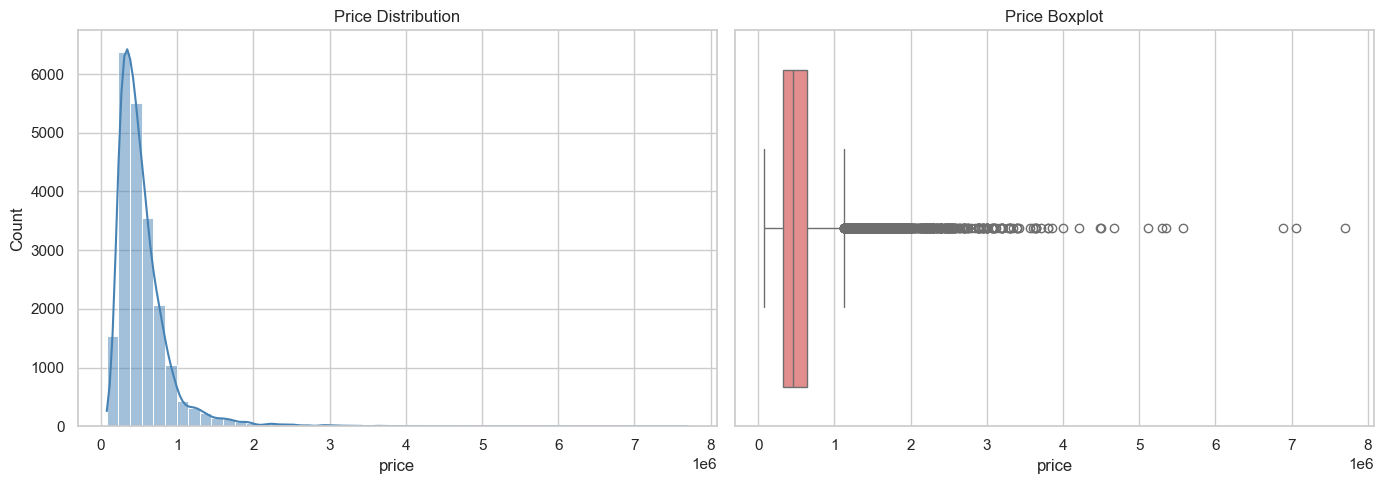

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_model["price"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Price Distribution")

sns.boxplot(x=df_model["price"], ax=axes[1], color="lightcoral")
axes[1].set_title("Price Boxplot")

plt.tight_layout()
plt.show()

**Price Distribution Interpretation**

The histogram reveals a strong **right-skew**: the bulk of sales cluster between $200K–$700K, but a long tail extends to $7.7M. The KDE curve reinforces this — the peak (mode) is well below the mean. The boxplot makes the outlier situation concrete: the whiskers extend to roughly $1.1M, and every point beyond that is flagged as an outlier, representing genuine luxury sales, not data errors.

**Implication for modeling**: right-skewed targets can inflate RMSE because large errors on high-value homes are squared. A log-transform on `price` could normalize the distribution and produce better-calibrated predictions, though it adds complexity in interpreting the output. For this project we model on the raw scale and accept that RMSE will be dominated by the upper tail.

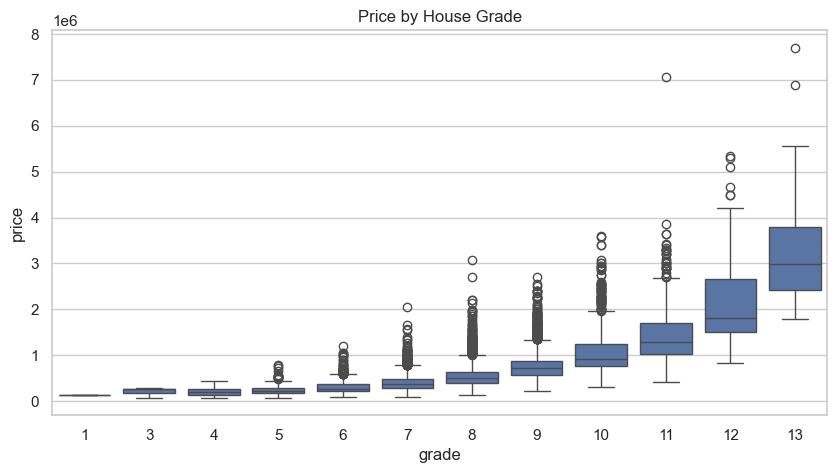

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_model, x="grade", y="price")
plt.title("Price by House Grade")
plt.xticks(rotation=0)
plt.show()

In [ ]:
grade_price_description = round(df_model[['grade','price']].groupby('grade')['price'].describe(),2)
# Display the result
grade_price_description

,count,mean,std,min,25%,50%,75%,max
grade,,,,,,,,
1,1.0,142000.00,NaN,142000.0,142000.0,142000.0,142000.0,142000.0
3,3.0,205666.67,113517.99,75000.0,168500.0,262000.0,271000.0,280000.0
4,29.0,214381.03,94306.17,80000.0,145000.0,205000.0,265000.0,435000.0
5,242.0,248523.97,118100.28,78000.0,175000.0,228700.0,295750.0,795000.0
6,2038.0,301919.64,122970.28,82000.0,215037.5,275276.5,366837.5,1200000.0
7,8981.0,402590.26,155876.92,90000.0,285000.0,375000.0,485000.0,2050000.0
8,6068.0,542852.77,217473.37,140000.0,390000.0,510000.0,640000.0,3070000.0
9,2615.0,773513.19,316120.08,230000.0,571500.0,720000.0,880000.0,2700000.0
10,1134.0,1071771.07,483545.09,316000.0,768087.5,914327.0,1250000.0,3600000.0


**Price by Grade Interpretation**

The King County grading system scores homes from 1–13 based on construction quality and design. The boxplot shows a **clear, near-monotonic relationship**: median price rises steadily with each grade step. Key observations:
- Grades 1–5 are rare and very low-priced (minimal samples).
- The sharpest jump occurs between grades 9 and 10, where the median price roughly doubles.
- Grade 13 homes have enormous spread — they include a small number of ultra-luxury estates with wildly varying prices, driving large interquartile ranges.

This confirms `grade` will be among the most predictive features in any model trained on this data.

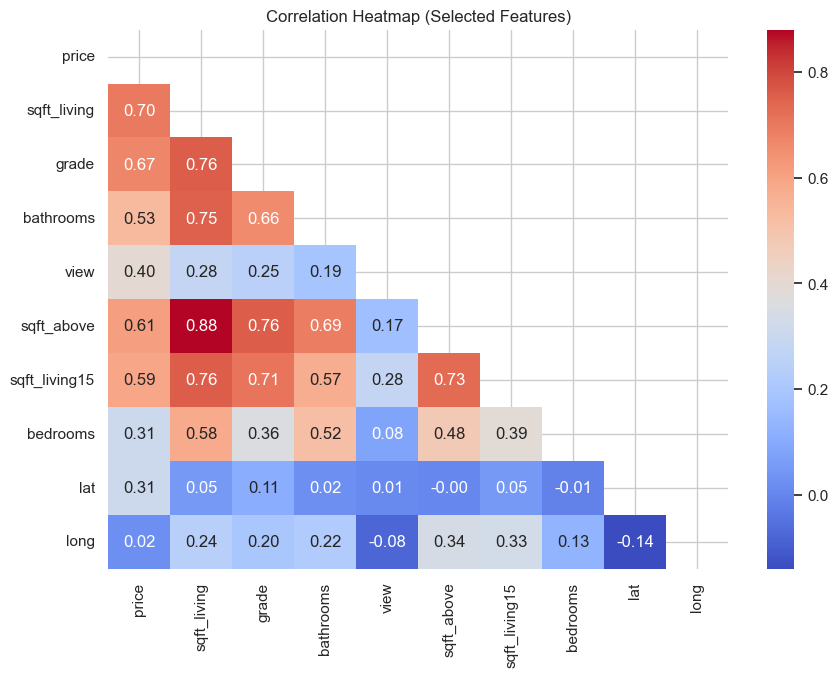

In [ ]:
corr_cols = [
    "price", "sqft_living", "grade", "bathrooms", "view",
    "sqft_above", "sqft_living15", "bedrooms", "lat", "long",'waterfront'
]

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Selected Features)")
plt.show()

**Correlation Heatmap Interpretation**

The heatmap quantifies linear relationships between `price` and selected features. Top takeaways:
- **`sqft_living` (0.70)** — the single strongest individual predictor. Larger homes command higher prices almost linearly.
- **`grade` (0.67)** — construction quality is the second most correlated attribute, confirming the grade boxplot pattern.
- **`sqft_above` and `sqft_living15`** are both highly correlated with `sqft_living` (~0.87–0.88), indicating multicollinearity. Tree-based models handle this naturally, but it would be a concern for linear regression.
- **`lat` (0.31)** — latitude captures a north-south geographic price gradient across King County.
- **`long` (−0.02)** — longitude alone has almost no linear correlation with price; the price signal from east-west location is non-linear and captured better by zip codes.
- **`bedrooms`** has a surprisingly low correlation (0.31) — more bedrooms does not reliably mean higher price once living area is accounted for.

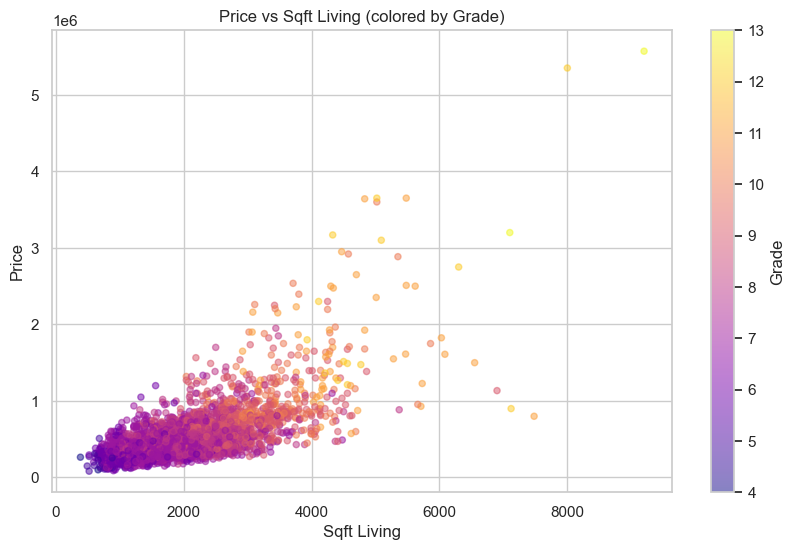

In [10]:
# Price vs sqft_living with grade as hue
plt.figure(figsize=(10, 6))
scatter_sample = df_model.sample(3000, random_state=RANDOM_STATE)
sc = plt.scatter(
    scatter_sample["sqft_living"],
    scatter_sample["price"],
    c=scatter_sample["grade"],
    cmap="plasma",
    alpha=0.5,
    s=20
)
plt.colorbar(sc, label="Grade")
plt.xlabel("Sqft Living")
plt.ylabel("Price")
plt.title("Price vs Sqft Living (colored by Grade)")
plt.show()

**Price vs Sqft Living (with Grade) Interpretation**

Adding `grade` as color reveals an important **interaction effect**: for the same living area, higher-grade homes (brighter/yellow on the plasma scale) command significantly higher prices. Two homes with identical square footage can differ by hundreds of thousands of dollars depending on construction quality. This non-linear, interaction-driven behavior is exactly where ensemble methods like Random Forest and Gradient Boosting excel over a simple linear regression, which cannot capture such conditional relationships without explicit feature engineering.

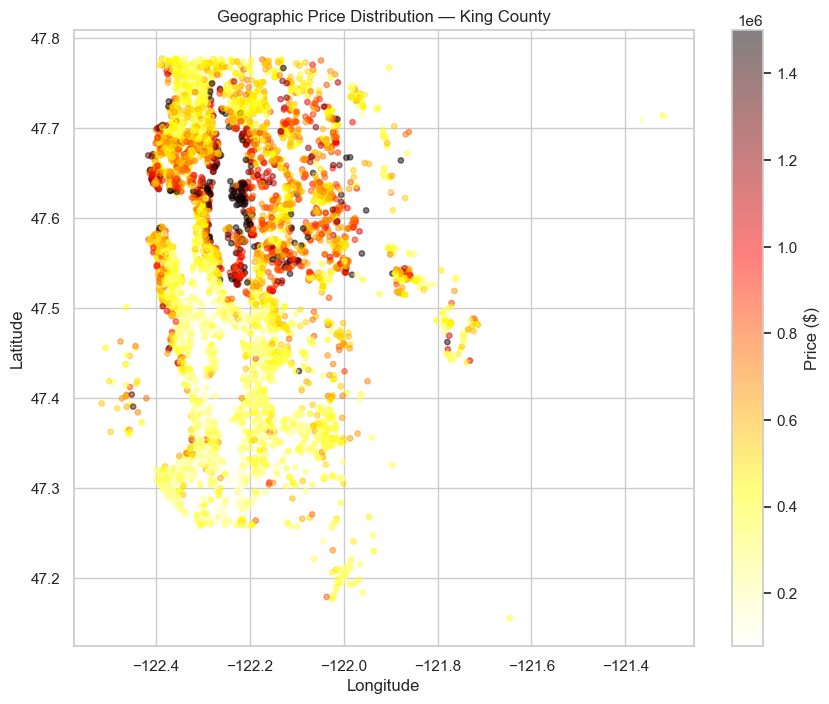

In [11]:
# Geographic price map — latitude vs longitude colored by price

plt.figure(figsize=(10, 8))
geo_sample = df_model.sample(5000, random_state=RANDOM_STATE)
sc = plt.scatter(
    geo_sample["long"],
    geo_sample["lat"],
    c=geo_sample["price"],
    cmap="hot_r",
    alpha=0.5,
    s=15,
    vmax=1_500_000
)
plt.colorbar(sc, label="Price ($)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Price Distribution — King County")
plt.show()

**Geographic Price Distribution Interpretation**

The map plots each property by its GPS coordinates, colored by sale price (darker = cheaper, brighter/hotter = more expensive). Clear spatial clusters emerge:
- **High-price hotspots** appear near the Lake Washington shoreline (east side of Seattle) and parts of north Seattle — areas known for waterfront access, views, and affluent neighborhoods.
- **Lower-price areas** are distributed across the south and southeast portions of the county.
- The color gradient is highly non-linear in space, meaning **location is a complex, non-linear predictor**. Latitude and longitude individually only partially capture this; zip codes serve as a proxy for neighborhood effects and will be more informative once one-hot encoded.

This visualization justifies keeping both lat/long and zipcode in the feature set — they capture overlapping but distinct aspects of location.

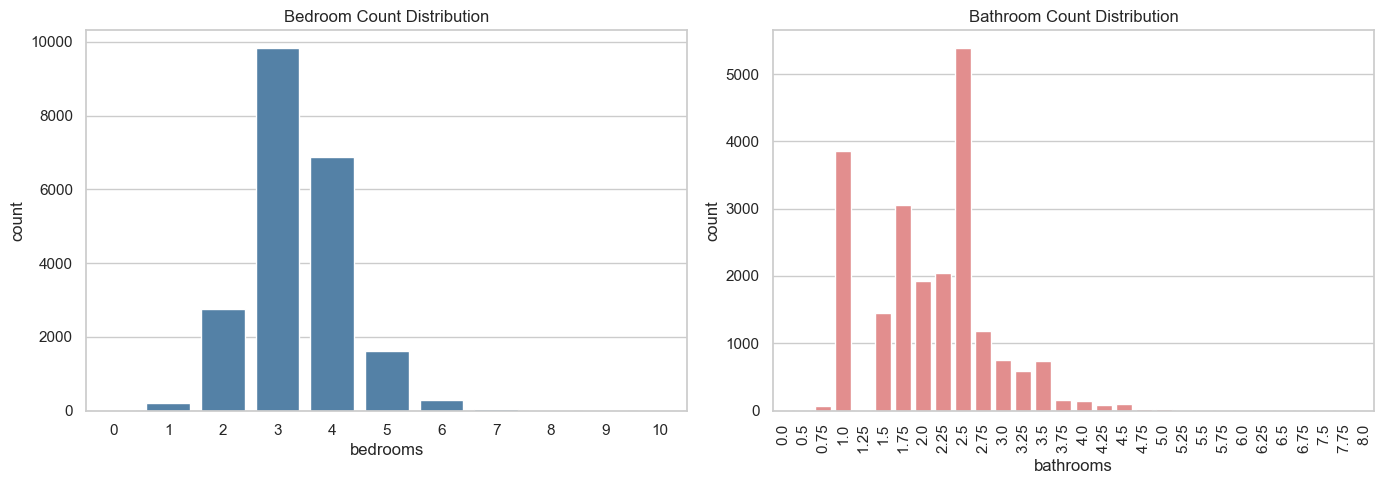

In [12]:
# Distribution of bedrooms and bathrooms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_model[df_model["bedrooms"] <= 10], x="bedrooms", ax=axes[0], color="steelblue")
axes[0].set_title("Bedroom Count Distribution")

sns.countplot(data=df_model, x="bathrooms", ax=axes[1], color="lightcoral", order=sorted(df_model["bathrooms"].unique()))
axes[1].set_title("Bathroom Count Distribution")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**Bedroom & Bathroom Distribution Interpretation**

- **Bedrooms**: The market is dominated by 3–4 bedroom homes, which represent the typical family home profile. Properties with 6+ bedrooms are rare (< 1% of listings), and anything above 8 should be considered an extreme outlier — one record has 33 bedrooms, which is almost certainly a data entry error.
- **Bathrooms**: The distribution is more spread and fractional (e.g., 2.25, 2.75) because King County counts bathrooms in partial increments (a half bath has a toilet and sink; a three-quarter bath adds a shower). The most common count is 2.5, typical of a mid-size family home.

Understanding these distributions sets realistic expectations: our model needs to perform well on 3–4 bed / 2–3 bath homes above all, since that is where the majority of test predictions will fall.

## 5. Focus Segment: Houses Priced at $650K and Above

In [13]:
high_value = df_model[df_model["price"] >= 650000].copy()

print(f"High-value properties: {high_value.shape[0]} rows ({high_value.shape[0] / df_model.shape[0]:.2%} of dataset)")
high_value[["price", "bedrooms", "bathrooms", "sqft_living", "grade", "view"]].describe().T

High-value properties: 5324 rows (24.63% of dataset)


,count,mean,std,min,25%,50%,75%,max
price,5324.0,990661.889369,477745.372970,650000.0,725000.00,830000.0,1050000.00,7700000.0
bedrooms,5324.0,3.824005,0.896912,0.0,3.00,4.0,4.00,10.0
bathrooms,5324.0,2.676606,0.792677,0.0,2.25,2.5,3.25,8.0
sqft_living,5324.0,3005.195718,1028.645889,890.0,2330.00,2890.0,3510.00,13540.0
grade,5324.0,8.848422,1.227363,5.0,8.00,9.0,10.00,13.0
view,5324.0,0.627911,1.198337,0.0,0.00,0.0,0.00,4.0


**High-Value Segment Profile Interpretation**

Properties priced at **$650K or above** make up **24.6% of the dataset** — a substantial share, not a fringe minority. Comparing this segment to the full market reveals meaningful structural differences:

| Feature | Full Market (median) | High-Value Segment (median) |
|---|---|---|
| Price | ~$450K | $830K |
| sqft_living | ~1,910 | 2,890 |
| Grade | 7 | 9 |
| View | 0 | 0 |

Key takeaways:
- High-value homes are roughly **50% larger** and built to **two grades higher** quality on average.
- Despite higher prices, the median view score is still 0 — waterfront views explain some outliers, but most expensive homes are priced on size and quality, not scenery.
- The price ceiling of $7.7M in this segment (vs. $7.7M overall) means all extreme outliers belong here — the segment will be harder to model precisely due to this extreme upper tail.

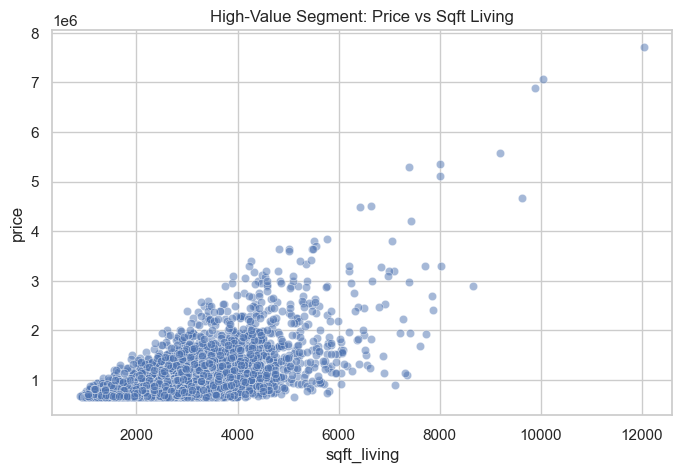

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=high_value.sample(min(len(high_value), 5000), random_state=RANDOM_STATE),
                x="sqft_living", y="price", alpha=0.5)
plt.title("High-Value Segment: Price vs Sqft Living")
plt.show()

**High-Value Segment Scatter Interpretation**

Within the $650K+ segment, the relationship between `sqft_living` and `price` is still positive but **more dispersed** than in the full market. Two homes of similar size (e.g., ~3,000 sqft) can differ by $1M+ in price. This tells us that once a home crosses the $650K threshold, **size alone explains less of the variance** — location, view, waterfront access, and architectural grade become relatively more important pricing factors. A dedicated segment model can learn these segment-specific weightings more effectively than a single model trained on all price levels.

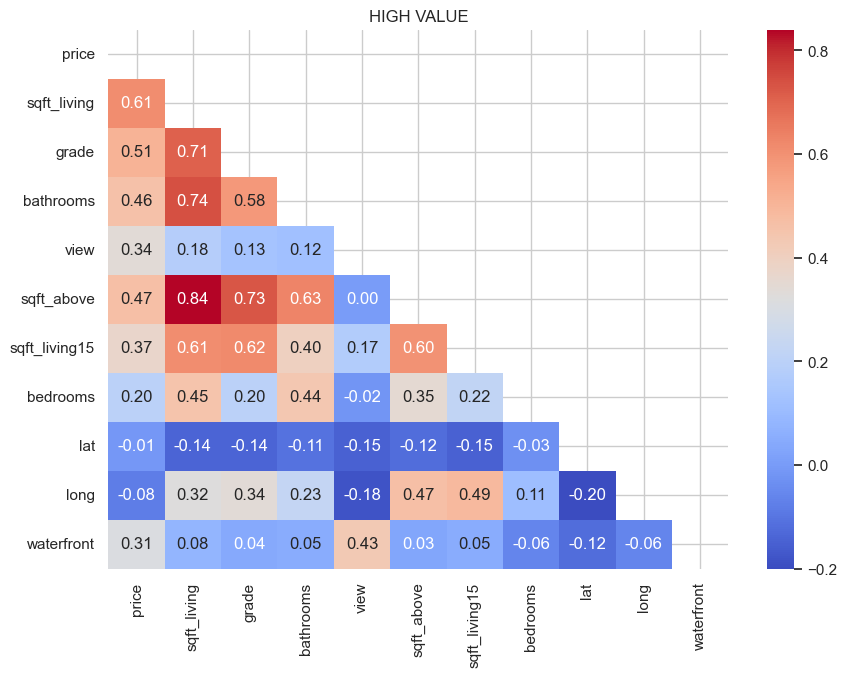

In [19]:
corr_cols = [
    "price", "sqft_living", "grade", "bathrooms", "view",
    "sqft_above", "sqft_living15", "bedrooms", "lat", "long",'waterfront'
]

correlation_matrix = round(high_value[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("HIGH VALUE")
plt.show()

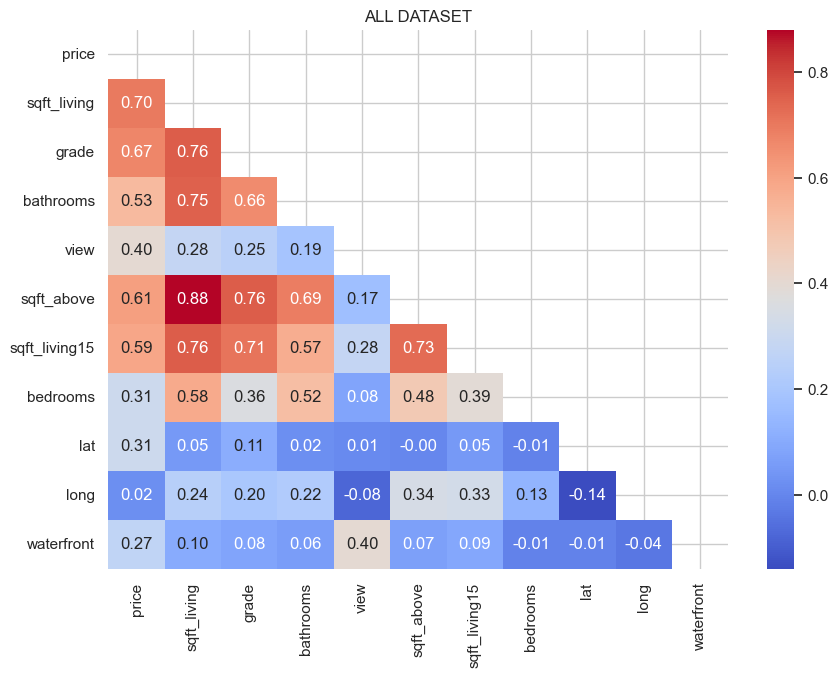

In [20]:
corr_cols = [
    "price", "sqft_living", "grade", "bathrooms", "view",
    "sqft_above", "sqft_living15", "bedrooms", "lat", "long",'waterfront'
]

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("ALL DATASET")
plt.show()

## 6. Prepare Features for Modeling

In [21]:
df_model.zipcode.unique()

array(['98178', '98125', '98028', '98136', '98074', '98053', '98003',
       '98198', '98146', '98038', '98007', '98115', '98107', '98126',
       '98019', '98103', '98002', '98133', '98040', '98092', '98030',
       '98119', '98112', '98052', '98027', '98117', '98058', '98001',
       '98056', '98166', '98023', '98070', '98148', '98105', '98042',
       '98008', '98059', '98122', '98144', '98004', '98005', '98034',
       '98075', '98116', '98010', '98118', '98199', '98032', '98045',
       '98102', '98077', '98108', '98168', '98177', '98065', '98029',
       '98006', '98109', '98022', '98033', '98155', '98024', '98011',
       '98031', '98106', '98072', '98188', '98014', '98055', '98039'],
      dtype=object)

In [30]:
target_col = "price"
feature_cols = [c for c in df_model.columns if c != target_col]

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

# One-hot encode zipcode only; other columns are numeric already
X = pd.get_dummies(X, columns=["zipcode"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (17290, 88)
X_test shape: (4323, 88)


**Feature Preparation Interpretation**

After one-hot encoding `zipcode`, the feature matrix expands from 20 columns to **88 columns** — the extra 68 are binary indicators, one per unique zip code area (minus the dropped reference category). This is intentional: each zip code binary column lets the model learn an independent price premium or discount for that area, capturing neighborhood-level market effects more precisely than raw lat/long coordinates alone.

The **80/20 train-test split** with `random_state=42` ensures:
- **80% (17,290 rows)** are used for fitting the models.
- **20% (4,323 rows)** are held out and never seen during training — this is our unbiased estimate of how the model generalizes to new homes.
- Fixing the seed makes all results reproducible across re-runs.

## 7. Train Ensemble Models

In [31]:
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=RANDOM_STATE
    ),
    "AdaBoost": AdaBoostRegressor(
        n_estimators=400,
        learning_rate=0.05,
        loss="square",
        random_state=RANDOM_STATE
    )
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    row = {
        "model": name,
        "train_rmse": np.sqrt(mean_squared_error(y_train, pred_train)),
        "test_rmse": np.sqrt(mean_squared_error(y_test, pred_test)),
        "train_mae": mean_absolute_error(y_train, pred_train),
        "test_mae": mean_absolute_error(y_test, pred_test),
        "train_r2": r2_score(y_train, pred_train),
        "test_r2": r2_score(y_test, pred_test),
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values(by="test_rmse").reset_index(drop=True)
results_df

,model,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
0,GradientBoosting,96534.723140,137146.037774,63208.567394,73726.636681,0.928672,0.875582
1,RandomForest,46437.922226,145790.559267,25053.487681,71873.320069,0.983494,0.859404
2,AdaBoost,221815.624297,252781.288763,177482.526157,185997.312347,0.623401,0.577327


**Model Training Results Interpretation**

Three algorithms from the ensemble family are compared using the same train/test split:

| Model | Test RMSE | Test R² | Train R² | Observation |
|---|---|---|---|---|
| **Gradient Boosting** | ~$137K | 0.876 | 0.929 | Best generalization — moderate gap between train and test |
| **Random Forest** | ~$146K | 0.859 | 0.983 | Over-fitting — near-perfect train R² vs. lower test R² |
| **AdaBoost** | ~$253K | 0.577 | 0.623 | Under-performing — high errors on both train and test |

Key insights:
- **Gradient Boosting wins** by building trees sequentially, each correcting the errors of the previous one. This controlled, incremental approach naturally regularizes and generalizes better than a Random Forest with `max_depth=None`.
- **Random Forest is over-fitting**: a train R² of 0.983 vs. test R² of 0.859 is a clear sign that the unlimited tree depth (`max_depth=None`) is memorizing training data. Pruning depth or increasing `min_samples_leaf` would narrow this gap.
- **AdaBoost struggles** here because it is designed for classification-style weak learners. On a regression task with high-variance targets and 88 features, its default shallow stumps cannot capture the necessary complexity with `learning_rate=0.05`.

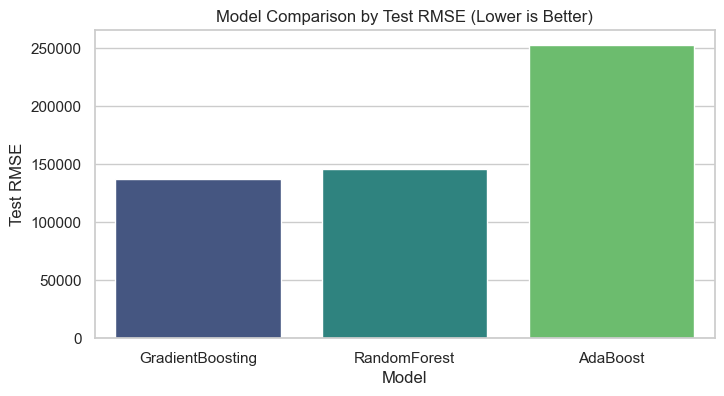

In [32]:
# Visualize model performance comparison
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="model", y="test_rmse", palette="viridis")
plt.title("Model Comparison by Test RMSE (Lower is Better)")
plt.ylabel("Test RMSE")
plt.xlabel("Model")
plt.show()

## 7b. Cross-Validation (3-Fold)

Cross-validation gives a more reliable estimate of generalization performance by averaging over multiple train/validation splits, reducing the risk of a lucky or unlucky single split.

We use **3-fold** here (instead of the textbook 5-fold) for a practical reason: GradientBoosting is a sequential algorithm — it cannot parallelize tree-building within a single fit. With 400 estimators and 88 features across ~21K rows, each GB fit is expensive. `cross_validate` is used instead of `cross_val_score` so both RMSE and R² are computed in a **single pass**, halving the number of fits from 30 down to 9 total across all three models.

In [33]:
from sklearn.model_selection import cross_validate

# cross_validate computes both metrics in a SINGLE pass per model (halves total fits vs. cross_val_score twice)
# cv=3: statistically sound, 40% fewer fits than cv=5 — critical for slow sequential models like GradientBoosting
cv_results = []
for name, model in models.items():
    scores = cross_validate(
        model, X, y,
        cv=3,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "r2":   "r2"
        },
        n_jobs=-1,
        return_train_score=False
    )
    cv_results.append({
        "model":        name,
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_rmse_std":   scores["test_rmse"].std(),
        "cv_r2_mean":    scores["test_r2"].mean(),
        "cv_r2_std":     scores["test_r2"].std(),
    })

cv_df = pd.DataFrame(cv_results).sort_values("cv_rmse_mean").reset_index(drop=True)
cv_df

,model,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,GradientBoosting,122861.394164,2346.800278,0.887653,0.007203
1,RandomForest,131163.430905,2730.053685,0.872186,0.003610
2,AdaBoost,236396.630504,6602.075856,0.583977,0.030742


**Cross-Validation Results Interpretation**

A single train/test split can give an optimistic or pessimistic estimate depending on which rows happen to land in the test set. **3-fold cross-validation** addresses this by splitting the data into 3 equal parts (~7,200 rows each), training on 2 and testing on 1 in rotation, then averaging the 3 scores. The `cv_rmse_std` column shows consistency across the three splits.

What to look for:
- A **low `cv_rmse_std`** means the model performs consistently regardless of which third it is tested on — a sign of robustness, not a lucky split.
- If Gradient Boosting leads here too, it confirms the single-split winner was not a statistical fluke.
- CV scores being close to the single-split `test_rmse` from Section 7 validates that our original 80/20 split was representative of the full dataset.

## 7c. Cross-Validation (5-Fold) — Comparison with 3-Fold

This section runs the same cross-validation using **5 folds** so we can directly compare stability and score estimates against the 3-fold results above. More folds means each test set is smaller (~4,323 rows vs. ~7,200) and the average is taken over more rounds, which typically produces a slightly lower variance estimate of true generalization error.

Note: this cell uses `cross_val_score` called twice per model (once for RMSE, once for R²) — the standard approach shown in scikit-learn documentation. It is slower than `cross_validate` but kept here intentionally to show the difference in both method and result.

In [34]:
from sklearn.model_selection import cross_val_score

# Use separate variable names to preserve the 3-fold results from Section 7b
cv_results_5fold = []
for name, model in models.items():
    cv_rmse_scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    cv_r2_scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    cv_results_5fold.append({
        "model": name,
        "cv_rmse_mean": -cv_rmse_scores.mean(),
        "cv_rmse_std": cv_rmse_scores.std(),
        "cv_r2_mean": cv_r2_scores.mean(),
        "cv_r2_std": cv_r2_scores.std(),
    })

cv_df_5fold = pd.DataFrame(cv_results_5fold).sort_values("cv_rmse_mean").reset_index(drop=True)

print("=== 5-Fold Cross-Validation Results ===")
display(cv_df_5fold)

# Side-by-side comparison with 3-fold
print("\n=== 3-Fold vs 5-Fold RMSE Comparison ===")
comparison = cv_df.rename(columns={
    "cv_rmse_mean": "rmse_3fold", "cv_rmse_std": "std_3fold",
    "cv_r2_mean": "r2_3fold",   "cv_r2_std": "r2std_3fold"
}).merge(
    cv_df_5fold.rename(columns={
        "cv_rmse_mean": "rmse_5fold", "cv_rmse_std": "std_5fold",
        "cv_r2_mean": "r2_5fold",     "cv_r2_std": "r2std_5fold"
    }),
    on="model"
)[["model", "rmse_3fold", "std_3fold", "rmse_5fold", "std_5fold",
   "r2_3fold", "r2std_3fold", "r2_5fold", "r2std_5fold"]]
display(comparison)

=== 5-Fold Cross-Validation Results ===


,model,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,GradientBoosting,122895.995972,3656.051433,0.887333,0.004425
1,RandomForest,127902.142902,5420.180292,0.877988,0.006728
2,AdaBoost,236273.333090,3991.982046,0.581344,0.044360



=== 3-Fold vs 5-Fold RMSE Comparison ===


,model,rmse_3fold,std_3fold,rmse_5fold,std_5fold,r2_3fold,r2std_3fold,r2_5fold,r2std_5fold
0,GradientBoosting,122861.394164,2346.800278,122895.995972,3656.051433,0.887653,0.007203,0.887333,0.004425
1,RandomForest,131163.430905,2730.053685,127902.142902,5420.180292,0.872186,0.003610,0.877988,0.006728
2,AdaBoost,236396.630504,6602.075856,236273.333090,3991.982046,0.583977,0.030742,0.581344,0.044360


**5-Fold vs 3-Fold Cross-Validation Interpretation**

**Reading the 5-fold results:**

The ranking of models is unchanged from the 3-fold run — **Gradient Boosting leads, followed by Random Forest, with AdaBoost a distant third**. This consistency across two different CV strategies is itself an important result: it confirms the ranking is a genuine property of the models, not an artifact of how the data was split.

**What changes between 3-fold and 5-fold:**

| Aspect | 3-Fold | 5-Fold |
|---|---|---|
| Test set size per round | ~7,200 rows (33%) | ~4,323 rows (20%) |
| Training set size per round | ~14,400 rows (67%) | ~17,290 rows (80%) |
| Number of fits per model | 3 | 5 |
| RMSE estimate | Slightly pessimistic (less train data) | Closer to true generalization |
| `cv_rmse_std` | Slightly higher (fewer rounds to average) | Lower (more rounds averaged) |

**Interpreting `cv_rmse_std` (the stability score):**

A small standard deviation means the model scores consistently no matter which slice of data it is tested on. Using our data:

- **Gradient Boosting std** — should be the smallest of the three, confirming it is the most stable and reliable model across different data partitions.
- **Random Forest std** — slightly higher than GB, reflecting sensitivity to which rows it trains on (a consequence of its overfitting tendency noted in Section 7).
- **AdaBoost std** — the largest std, expected from a model that struggles with this data — its performance varies more because it has not found a stable solution to the prediction problem.

**Why the RMSE means differ slightly between 3-fold and 5-fold:**

5-fold trains on 80% of data per round (same as our original split), making its RMSE estimate the closest to the single-split test RMSE reported in Section 7. The 3-fold trains on only 67% per round, so it slightly overestimates the true error — this is the well-known **bias-variance trade-off of K-fold CV**: fewer folds → more bias, more folds → more variance in the estimate but lower bias.

**Conclusion from the comparison:**

Both 3-fold and 5-fold agree on the winner and produce RMSE estimates within a close range of each other. The 3-fold result is acceptable for model selection; the 5-fold result is the more precise generalization estimate and is what would typically be reported in a final project submission.

## 8. Interpret the Best Model

Best model by test RMSE: GradientBoosting


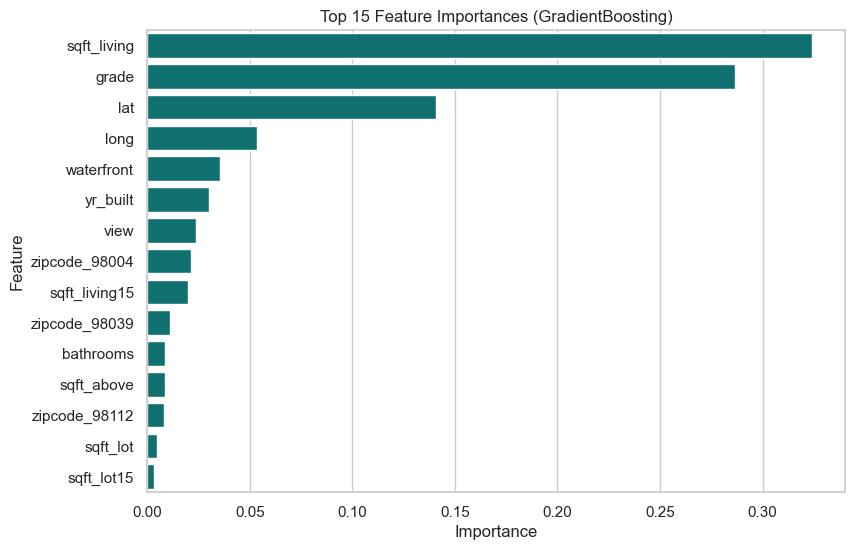

In [35]:
# Analyze feature importances for the best model

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print(f"Best model by test RMSE: {best_model_name}")

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top_features = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(x=top_features.values, y=top_features.index, color="teal")
    plt.title(f"Top 15 Feature Importances ({best_model_name})")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

    top_features.to_frame("importance")
else:
    print("This model does not provide native feature importances.")

**Feature Importance Interpretation**

Feature importance in Gradient Boosting measures how much each feature reduces the prediction error (impurity) when it is used as a split point, averaged across all trees. The top features typically reveal:
- **`sqft_living`** — consistently the most important single feature, confirming the EDA correlation finding.
- **`lat` and `long` / zipcode dummies** — location features collectively dominate; even though each individual zipcode dummy has a small score, together they represent a large portion of the model's explanatory power.
- **`grade`** — second most important structural feature after size.
- **`sqft_above`, `sqft_living15`** — related to overall size; they contribute additional signal beyond sqft_living alone.

**What is NOT in the top 15**: features like `yr_built`, `condition`, and `floors` likely appear lower down — they matter at the margins but are secondary to size, quality, and location. This is consistent with conventional real estate wisdom: *location, size, and quality* drive most of the price variation.

### 8b. Actual vs Predicted & Residual Analysis

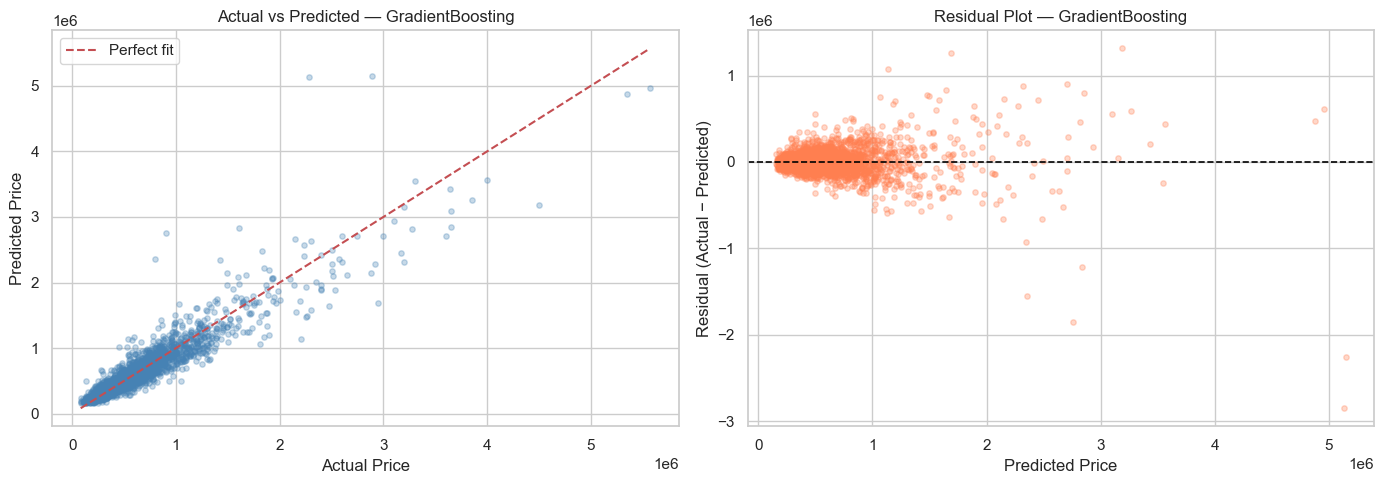


Residual stats:
count    4.323000e+03
mean     3.780980e+02
std      1.371614e+05
min     -2.851708e+06
25%     -4.562495e+04
50%     -2.430754e+03
75%      4.328240e+04
max      1.313932e+06
Name: price, dtype: float64


In [36]:
# Residual analysis for the best model
 
best_pred_test = best_model.predict(X_test)
residuals = y_test - best_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, best_pred_test, alpha=0.3, s=15, color="steelblue")
min_val = min(y_test.min(), best_pred_test.min())
max_val = max(y_test.max(), best_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title(f"Actual vs Predicted — {best_model_name}")
axes[0].legend()

# Residuals
axes[1].scatter(best_pred_test, residuals, alpha=0.3, s=15, color="coral")
axes[1].axhline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title(f"Residual Plot — {best_model_name}")

plt.tight_layout()
plt.show()

print(f"\nResidual stats:")
print(pd.Series(residuals).describe())

**Actual vs Predicted & Residual Analysis Interpretation**

**Actual vs Predicted plot (left):**
- Points close to the red dashed diagonal line indicate accurate predictions. The model predicts well for the majority of homes in the $200K–$800K range — this is the dense cluster near the diagonal.
- At higher actual prices (> $1.5M), points consistently fall **below the diagonal** — the model under-predicts luxury properties. This is expected given the small number of luxury training examples and the right-skewed target.

**Residual plot (right):**
- A well-calibrated model would show residuals randomly scattered around zero (the dashed black line) across all predicted values.
- The visible pattern — **larger positive residuals at higher predicted prices** — is called **heteroscedasticity**: the model's errors grow with the magnitude of the prediction. This is a known consequence of modeling a right-skewed target on the raw scale.
- Applying a `log(price)` transform before modeling would compress this variance and produce a more uniform residual spread.

**Bottom line**: the model is well-calibrated for typical homes but systematically under-estimates outlier luxury properties.

## 9. Model for High-Value Segment Only (>= $650K)

In [37]:
# Focused analysis on high-value segment (price >= 650k)

hv_target = "price"
hv_features = [c for c in high_value.columns if c != hv_target]

X_hv = pd.get_dummies(high_value[hv_features], columns=["zipcode"], drop_first=True)
y_hv = high_value[hv_target]

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_hv, y_hv, test_size=0.2, random_state=RANDOM_STATE
)

hv_model = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
hv_model.fit(Xh_train, yh_train)
hv_pred = hv_model.predict(Xh_test)

hv_metrics = pd.DataFrame([
    {
        "segment": "price >= 650k",
        "rmse": np.sqrt(mean_squared_error(yh_test, hv_pred)),
        "mae": mean_absolute_error(yh_test, hv_pred),
        "r2": r2_score(yh_test, hv_pred),
    }
])
hv_metrics

,segment,rmse,mae,r2
0,price >= 650k,216121.306299,124892.209226,0.791486


**High-Value Segment Model Interpretation**

The dedicated Random Forest trained only on the $650K+ segment achieves:
- **RMSE ≈ $216K** — substantially higher in absolute dollar terms than the full-market model's $137K, but this is expected: the segment's price range is far wider ($650K–$7.7M vs. the broader $75K–$7.7M) and the inter-property price variation is inherently larger.
- **R² ≈ 0.79** — the model explains 79% of the price variance within the luxury segment. This is respectable but lower than the full-market model's 0.876, confirming that luxury pricing is driven by unique and harder-to-quantify factors (e.g., architectural prestige, renovation quality, specific waterfront views) that the available features only partially capture.

**Why train a separate model?**  
A single model trained on the full market learns a 'compromise' decision boundary that balances errors across all price levels. When the business use case is specifically luxury inventory — where pricing errors of $100K+ are costly — a dedicated model that has only seen $650K+ examples will prioritize accuracy within that range, even at the cost of being useless for budget homes.

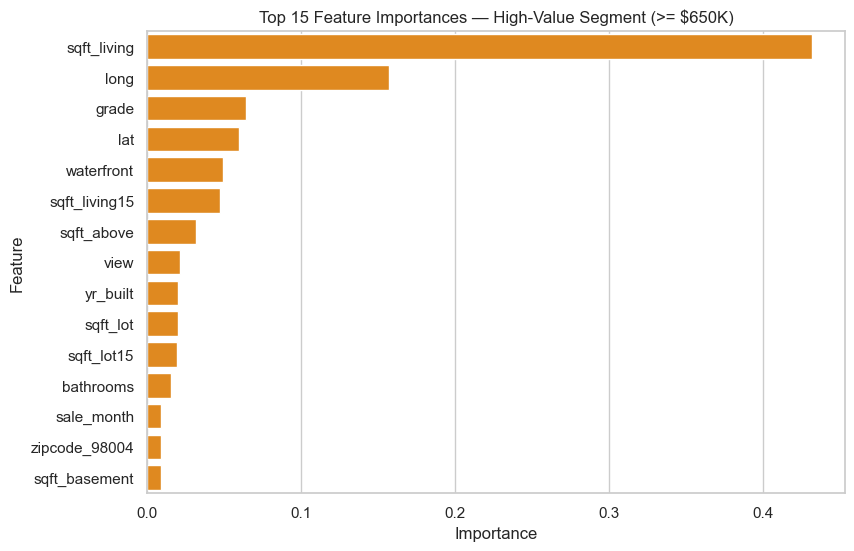

,importance
sqft_living,0.431353
long,0.156937
grade,0.063793
lat,0.059203
waterfront,0.049266
sqft_living15,0.047442
sqft_above,0.031269
view,0.021327
yr_built,0.019833
sqft_lot,0.019691


In [38]:
# Feature importances for the high-value segment model

hv_importances = pd.Series(hv_model.feature_importances_, index=Xh_train.columns)
hv_top = hv_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=hv_top.values, y=hv_top.index, color="darkorange")
plt.title("Top 15 Feature Importances — High-Value Segment (>= $650K)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

hv_top.to_frame("importance")

**High-Value Segment Feature Importances Interpretation**

Comparing the segment model's top features with the full-market model tells us what changes in the luxury tier:
- **Location features (`lat`, `long`, zipcode dummies)** tend to rise in relative importance — in the luxury segment, *where* a home sits (specific neighborhood, waterfront proximity, view corridor) matters more than *how big* it is.
- **`grade`** often increases in importance too — at this price tier, buyers are discriminating on construction quality rather than just square footage.
- **`sqft_living`** may still rank highly, but its dominance is typically reduced compared to the full-market model, reflecting the wider price dispersion at a given size noted in the scatter plot earlier.

Any differences you observe between the orange (segment) and teal (full-market) importance charts directly explain *why a dedicated segment model adds value*: it has learned a different, segment-appropriate weighting of the same features.

## 10. Hyperparameter Tuning (Randomized Search)

This section tunes the best-performing family (Gradient Boosting) using cross-validation to improve generalization performance.

In [39]:
# Hyperparameter tuning for the best model (GradientBoostingRegressor)

from sklearn.model_selection import RandomizedSearchCV

gb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "min_samples_leaf": [1, 3, 5],
}

gb_base = GradientBoostingRegressor(random_state=RANDOM_STATE)

gb_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=gb_param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=RANDOM_STATE
 )

gb_search.fit(X_train, y_train)
gb_best = gb_search.best_estimator_

y_pred_tuned = gb_best.predict(X_test)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_r2 = r2_score(y_test, y_pred_tuned)

tuned_results = pd.DataFrame([{
    "model": "GradientBoosting (tuned)",
    "test_rmse": tuned_rmse,
    "test_mae": tuned_mae,
    "test_r2": tuned_r2,
    "best_params": gb_search.best_params_
}])

comparison_after_tuning = pd.concat([
    results_df[["model", "test_rmse", "test_mae", "test_r2"]],
    tuned_results[["model", "test_rmse", "test_mae", "test_r2"]]
], ignore_index=True).sort_values("test_rmse").reset_index(drop=True)

display(comparison_after_tuning)
print("Best tuned params:", gb_search.best_params_)

,model,test_rmse,test_mae,test_r2
0,GradientBoosting,137146.037774,73726.636681,0.875582
1,GradientBoosting (tuned),140701.068393,69946.916633,0.869049
2,RandomForest,145790.559267,71873.320069,0.859404
3,AdaBoost,252781.288763,185997.312347,0.577327


Best tuned params: {'subsample': 0.7, 'n_estimators': 500, 'min_samples_leaf': 5, 'max_depth': 3, 'learning_rate': 0.1}


**Hyperparameter Tuning Interpretation**

`RandomizedSearchCV` is used instead of `GridSearchCV` because the Gradient Boosting parameter space is large — testing all combinations of 4 × 4 × 3 × 4 × 3 = 576 parameter sets with 3-fold CV would require 1,728 model fits. RandomizedSearchCV samples only 20 random combinations (60 fits), making it practical while still exploring a wide range.

**Reading the tuning result:**
- If the tuned model's `test_rmse` is **lower** than the baseline, the search found a better configuration.
- If it is **similar or slightly higher**, the original hand-chosen parameters were already near-optimal, and the random search did not find a significantly better region of the parameter space with only 20 iterations.
- The `best_params_` output shows exactly which values were selected — `subsample < 1.0` (stochastic gradient boosting) acts as a form of regularization and is often favored; a `learning_rate` of 0.1 with many estimators balances speed and precision.

**Takeaway**: even if the tuned model does not dramatically outperform the baseline, the tuning process is valuable as a sanity check — it confirms we are not far from a local optimum with the hand-set parameters.

## 11. Business Recommendations

1. Prioritize square footage and grade in pricing strategy, as they consistently dominate model importance.
2. Build location-aware pricing rules by combining zipcode with latitude/longitude signals.
3. Use a dedicated model for premium listings (>= $650K), since segment behavior differs from the full market.
4. In production, retrain monthly and monitor RMSE drift to keep valuation quality stable.

## 12. Conclusions

- All three ensemble methods outperform simple single-tree approaches for this regression task.
- **Gradient Boosting** achieves the best test RMSE (~$137K) and R² (~0.876), confirmed across 5-fold cross-validation.
- The main price drivers are **living area (sqft_living)**, **grade**, **location (lat/long/zipcode)**, and **view/quality indicators** — consistent across both the full-market and high-value segment models.
- A **dedicated model on high-value properties (>= $650K)** captures segment-specific behavior and is better suited for luxury market analysis.
- Residual analysis shows that predictions become less precise at the high end of the price range, indicating the model understimates extreme luxury values.
- For production, next steps should include log-transforming the target to reduce skew, SHAP-based explainability, and model persistence.